# Electronics Product Quality Snapshot

This notebook prepares a small, reviewable product quality dataset for the Transformational AI machine learning team. The workflow uses a 100 row stream from Amazon Electronics reviews and a 100 row stream from product metadata. The result focuses on products with a title, an average rating of at least 4.5, and a usable price.

The analysis keeps the data pull intentionally small so the workflow is fast to inspect while still demonstrating a safe pattern for much larger files. The final table is saved in both CSV and Parquet formats for downstream analysis.

## 1. Environment and library check

The required libraries are imported before analysis begins. Version information is printed so the execution environment can be checked quickly. If a fresh environment is being used, the following command installs the project dependencies:

```python
%pip install datasets pandas matplotlib seaborn pyarrow
```

In [1]:
import importlib.metadata as importlib_metadata
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset


required_packages = {
    "datasets": "datasets",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "pyarrow": "pyarrow",
}

os.environ["PATH"] = f"{Path(sys.executable).parent}:{os.environ.get('PATH', '')}"
print("Command line version checks:")
!python --version
!jupyter-notebook --version
print(f"Python: {sys.version.split()[0]}")
print(f"Python executable: {sys.executable}")
try:
    notebook_version = importlib_metadata.version("notebook")
except importlib_metadata.PackageNotFoundError:
    notebook_version = "not installed"
print(f"Jupyter Notebook package: {notebook_version}")

missing_packages = []
for package_name, distribution_name in required_packages.items():
    try:
        version = importlib_metadata.version(distribution_name)
        print(f"{package_name}: {version}")
    except importlib_metadata.PackageNotFoundError:
        missing_packages.append(package_name)

assert not missing_packages, f"Missing required packages: {missing_packages}"
assert sys.version_info >= (3, 9), "Python 3.9 or newer is required."
print("Environment check passed.")

/Users/aloksapre/Documents/ChatGPT/electronics-product-quality-snapshot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Command line version checks:


Python 3.12.13


7.1.2


Python: 3.12.13
Python executable: /Users/aloksapre/Documents/ChatGPT/electronics-product-quality-snapshot/.venv/bin/python
Jupyter Notebook package: 7.1.2
datasets: 3.0.1
pandas: 2.2.3
matplotlib: 3.9.2
seaborn: 0.13.2
pyarrow: 17.0.0
Environment check passed.


## 2. Review sample

The source is streamed from the `raw_review_Electronics` configuration. Only the first 100 records are collected. `streaming=True` and `trust_remote_code=True` are explicit boolean settings, and the loop stops as soon as the sample limit is reached.

In [2]:
sample_limit = 100
stream_reviews = True
allow_dataset_code = True

reviews_dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full",
    streaming=stream_reviews,
    trust_remote_code=allow_dataset_code,
)

review_rows = []
for index, review in enumerate(reviews_dataset, start=1):
    review_rows.append(review)
    if index == sample_limit:
        break

reviews_df = pd.DataFrame(review_rows)
print(f"Review rows collected: {len(reviews_df)}")
reviews_df.head()

Review rows collected: 100


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


In [3]:
Items_To_Print = 10
pd.set_option("display.max_rows", Items_To_Print)
pd.set_option("display.max_columns", Items_To_Print)
pd.set_option("display.max_colwidth", 100)
print(f"Showing the first {Items_To_Print} review items:")
reviews_df.head(Items_To_Print)

Showing the first 10 review items:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum prod...,"[{'small_image_url': 'https://m.media-amazon.com/images/I/71YN+Qk3kCL._SL256_.jpg', 'medium_imag...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,"These didn’t work. Idk if they were damaged in shipping or what, but the lenses were loose or so...",[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case and several sizes of ear bud inserts. Thank heave...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for school that would allow me to carry my laptop as well ...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times because I love them so much and overuse them and find w...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True
5,5.0,Great Fan! I’m a FAN!,"Light weight, quiet and totally awesome!!! It doesn’t come with a charging base, but the cord en...",[],B072DSHKCH,B07CML419K,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1637522881041,0,True
6,5.0,solid sound for the price,Update 2-they sent a new warranty replacement. Good company.<br />Update- was 5 star until they...,[],B07BHHB5RH,B07BHHB5RH,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1565130879386,0,True
7,5.0,Love the headphones - great range,These are fantastic headphones and I love that i can have my cell phone plugged in at a central ...,[],B07BND376H,B09S6Y5BRG,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1541356831659,9,True
8,5.0,Five Stars,pretty good for the price.,[],B002HWRZ2K,B01LW71IBJ,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1456772571000,0,True
9,5.0,BUY THIS THANG,yes.. so good. just buy it. my favorite feature is it auto connects and remembers my devices.,[],B00WK47VEW,B017T99JPG,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1456772365000,0,True


## 3. Product metadata sample

The product stream uses the same 100 row limit. Product metadata contains the title, average rating, and price fields needed for the final dataset.

In [4]:
metadata_limit = 100
stream_metadata = True
allow_metadata_code = True

metadata_dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    split="full",
    streaming=stream_metadata,
    trust_remote_code=allow_metadata_code,
)

metadata_rows = []
for index, item in enumerate(metadata_dataset, start=1):
    metadata_rows.append(item)
    if index == metadata_limit:
        break

item_metadata_df = pd.DataFrame(metadata_rows)
print(f"Metadata rows collected: {len(item_metadata_df)}")
item_metadata_df.head()

Metadata rows collected: 100


,main_category,title,average_rating,rating_number,features,...,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],...,"{""Date First Available"": ""August 2, 2014"", ""Manufacturer"": ""Fatshark""}",B00MCW7G9M,None,None,None
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",...,"{""Product Dimensions"": ""0.83 x 4.17 x 2.05 inches"", ""Item Weight"": ""5.3 ounces"", ""Item model num...",B00YT6XQSE,None,None,None
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protecti...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the bottom of your Macbook. Only fits for model A2338/...,...,"{""Brand"": ""Digi-Tatoo"", ""Color"": ""Fresh Marble"", ""Room Type"": ""Bedroom"", ""Material"": ""Vinyl"", ""T...",B07SM135LS,None,None,None
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactive 4 / Samsung Gear S3 Classic / S3 Frontier / Gear...,...,"{""Date First Available"": ""May 29, 2020"", ""Manufacturer"": ""NotoCity""}",B089CNGZCW,None,None,None
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive Package Incredible Value Worth $145!!!, Includes a...",...,"{""Product Dimensions"": ""11.6 x 6.9 x 3.1 inches"", ""Item Weight"": ""1.5 pounds"", ""Other display fe...",B004E2Z88O,None,None,None


In [5]:
print("Reviews sample columns and data types:")
print(reviews_df.head().dtypes)
print("\nMetadata sample columns and data types:")
print(item_metadata_df.head().dtypes)

Reviews sample columns and data types:
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

Metadata sample columns and data types:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
                    ...   
details             object
parent_asin         object
bought_together     object
subtitle            object
author              object
Length: 16, dtype: object


### Safe product lookup

Prices can be missing or stored as text. The lookup function uses `try` and `except` so a missing product, missing title, or invalid price returns a readable message instead of stopping the notebook.

In [6]:
def get_product(parent_asin, metadata_rows):
    '''Return a product title and numeric price, or a useful error message.'''
    try:
        matches = [item for item in metadata_rows if item.get("parent_asin") == parent_asin]
        if not matches:
            raise KeyError(f"No product found for parent_asin={parent_asin}")

        product = matches[0]
        title = product.get("title")
        if title is None or not str(title).strip():
            raise ValueError("The product title is missing")

        numeric_price = pd.to_numeric(product.get("price"), errors="coerce")
        if pd.isna(numeric_price):
            raise ValueError("The product price is missing or not numeric")

        return {"title": str(title).strip(), "price": float(numeric_price)}
    except (KeyError, TypeError, ValueError) as error:
        return f"Product lookup failed: {error}"


example_parent_asin = item_metadata_df.iloc[0]["parent_asin"]
print("Valid lookup:", get_product(example_parent_asin, metadata_rows))
print("Invalid lookup:", get_product("missing_parent_asin", metadata_rows))

numeric_prices = pd.to_numeric(item_metadata_df["price"], errors="coerce")
print(f"Metadata items with a usable price: {numeric_prices.notna().sum()}")
print(f"Metadata items without a usable price: {numeric_prices.isna().sum()}")

Valid lookup: Product lookup failed: The product price is missing or not numeric
Invalid lookup: Product lookup failed: 'No product found for parent_asin=missing_parent_asin'
Metadata items with a usable price: 44
Metadata items without a usable price: 56


## 4. Compare and summarize the data objects

In [7]:
dataframes_to_review = {
    "reviews_df": reviews_df,
    "item_metadata_df": item_metadata_df,
}

for dataframe_name, dataframe in dataframes_to_review.items():
    print(f"{dataframe_name} columns:")
    for column_name in dataframe.columns:
        print(column_name)
    print()

print("Review data types:")
print(reviews_df.dtypes)
print("\nMetadata data types:")
print(item_metadata_df.dtypes)

reviews_df columns:
rating
title
text
images
asin
parent_asin
user_id
timestamp
helpful_vote
verified_purchase

item_metadata_df columns:
main_category
title
average_rating
rating_number
features
description
price
images
videos
store
categories
details
parent_asin
bought_together
subtitle
author

Review data types:
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

Metadata data types:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
                    ...   
details             object
parent_asin         object
bought_together     object
subtitle            object
author              object
Length: 16, dtype: object


In [8]:
print("Reviews DataFrame summary:")
reviews_df.info()

print("\nMetadata DataFrame summary:")
item_metadata_df.info()

Reviews DataFrame summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             100 non-null    float64
 1   title              100 non-null    object 
 2   text               100 non-null    object 
 3   images             100 non-null    object 
 4   asin               100 non-null    object 
 5   parent_asin        100 non-null    object 
 6   user_id            100 non-null    object 
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 7.3+ KB

Metadata DataFrame summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----

## 5. Clean the product table

The three required fields are retained as `title`, `average_rating`, and `price`. The price column is converted with `errors="coerce"`, which changes missing or not numeric values to `NaN`. Those rows can then be excluded safely with a boolean filter.

In [9]:
item_metadata_df["price"] = pd.to_numeric(item_metadata_df["price"], errors="coerce")
average_rating_filter = 4.5

has_title = item_metadata_df["title"].notna() & item_metadata_df["title"].astype(str).str.strip().ne("")
has_required_rating = item_metadata_df["average_rating"].ge(average_rating_filter)
has_price = item_metadata_df["price"].notna()

clean_product_mask = has_title & has_required_rating & has_price
item_metadata_cleaned_df = item_metadata_df.loc[
    clean_product_mask, ["title", "average_rating", "price"]
].copy()
top_products_df = item_metadata_cleaned_df.reset_index(drop=True)

print(f"Clean products: {len(top_products_df)} of {len(item_metadata_df)}")
top_products_df.head(10)

Clean products: 21 of 100


,title,average_rating,price
0,Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protecti...,4.5,19.99
1,NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/...,4.5,9.99
2,Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gi...,4.7,8.98
3,ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet C...,5.0,909.99
4,BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB),5.0,98.49
5,"Outer Space Planets Stickers(50Pcs),Planetary Systems Waterproof Vinyl Water Bottle Stickers for...",4.5,3.99
6,Polaroid Originals Now Viewfinder i-Type Instant Camera (White) Bundle with Color and B and W In...,4.8,179.99
7,HP Elitebook 8560W New Replacement LCD Screen for Laptop LED HD Matte,4.7,63.33
8,May Chen Compatible with MacBook Pro 16 inch Case 2020 2019 Release A2141 with Touch Bar&Touch I...,4.5,26.99
9,"Wenlaty Case Compatible with iPad 9th /8th /7th Generation Case(2021/2020/2019), Full Body Prote...",4.7,19.99


In [10]:
def calculate_percentage(part, whole):
    '''Return part as a percentage of whole, with a safe zero check.'''
    if whole == 0:
        return 0.0
    return (part / whole) * 100


clean_percentage = calculate_percentage(len(top_products_df), len(item_metadata_df))
print(f"Percentage of metadata rows retained: {clean_percentage:.2f}%")

Percentage of metadata rows retained: 21.00%


### Export the analysis ready files

Both formats contain the same three cleaned columns. CSV is convenient for quick inspection, while Parquet keeps typed columns and is efficient for larger analytical workflows.

In [11]:
csv_path = Path("top_products.csv")
parquet_path = Path("top_products.parquet")

top_products_df.to_csv(csv_path, index=False)
top_products_df.to_parquet(parquet_path, index=False)

print(f"Saved {csv_path}: {csv_path.stat().st_size:,} bytes")
print(f"Saved {parquet_path}: {parquet_path.stat().st_size:,} bytes")
print("CSV columns:", pd.read_csv(csv_path).columns.tolist())
print("Parquet columns:", pd.read_parquet(parquet_path).columns.tolist())

Saved top_products.csv: 3,296 bytes
Saved top_products.parquet: 5,863 bytes
CSV columns: ['title', 'average_rating', 'price']
Parquet columns: ['title', 'average_rating', 'price']


In [12]:
top_rated_titles = []
for title in top_products_df["title"]:
    top_rated_titles.append(title)

print("Top rated product titles:")
for title in top_rated_titles:
    print(title)

Top rated product titles:
Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]
NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/First Avenger/Polar Vantage Smartwatch Sport Breathable Strap Replacement for Gear S3 Classic Watchband
Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gift (16GB, Camera Black)
ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive
BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB)
Outer Space Planets Stickers(50Pcs),Planetary Systems Waterproof Vinyl Water Bottle Stickers for Teens Girls Adults Kids,Laptop Car Cup Computer Guitar Skateboard Luggage Phone Aesthetic Stic

## 6. Visual findings

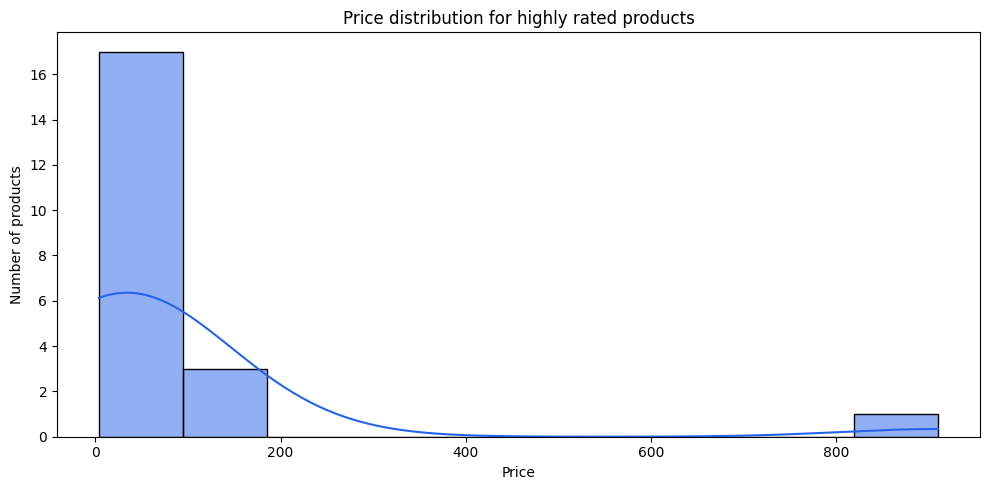

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(data=top_products_df, x="price", kde=True, color="#2563eb")
plt.title("Price distribution for highly rated products")
plt.xlabel("Price")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()

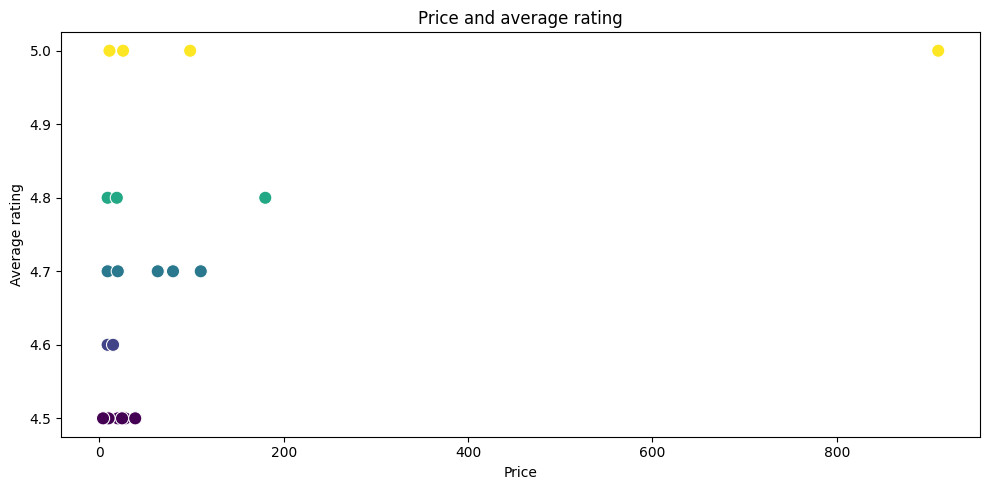

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=top_products_df,
    x="price",
    y="average_rating",
    hue="average_rating",
    palette="viridis",
    legend=False,
    s=90,
)
plt.title("Price and average rating")
plt.xlabel("Price")
plt.ylabel("Average rating")
plt.tight_layout()
plt.show()

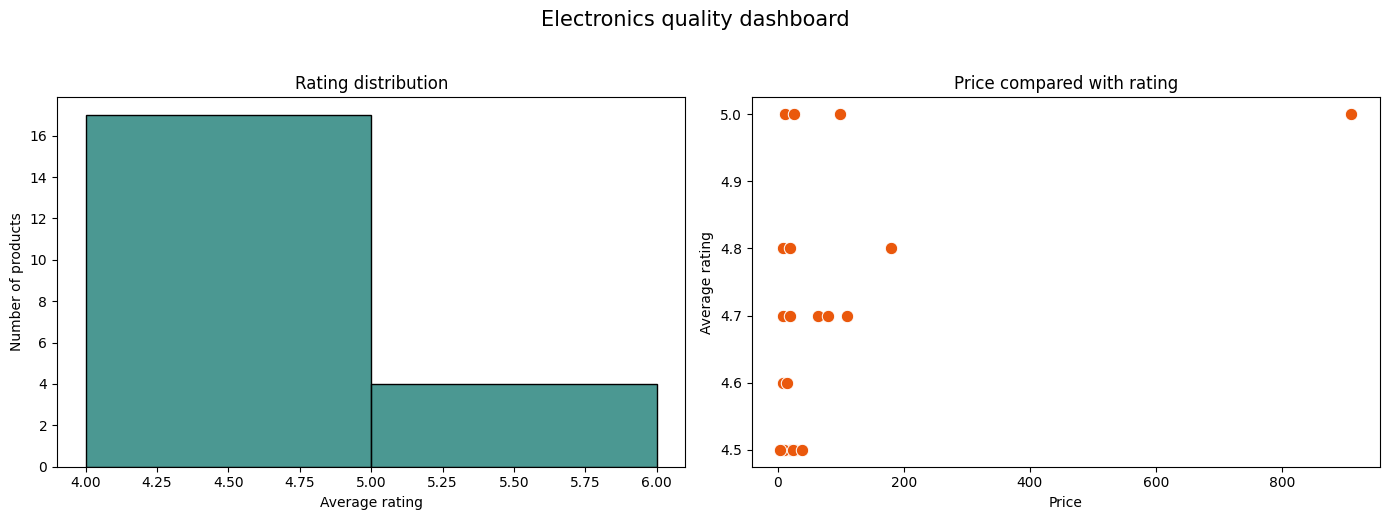

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=top_products_df, x="average_rating", discrete=True, ax=axes[0], color="#0f766e")
axes[0].set_title("Rating distribution")
axes[0].set_xlabel("Average rating")
axes[0].set_ylabel("Number of products")

sns.scatterplot(data=top_products_df, x="price", y="average_rating", ax=axes[1], color="#ea580c", s=80)
axes[1].set_title("Price compared with rating")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Average rating")

figure.suptitle("Electronics quality dashboard", y=1.03, fontsize=15)
figure.tight_layout()
plt.show()

### Focused view: ratings of 4.7 and above

The cutoff narrows the table to a small set of products that may be useful for a premium recommendation or satisfaction focused review.

In [16]:
highly_rated_products_df_cutoff = 4.7
highly_rated_products_df = (
    top_products_df.loc[top_products_df["average_rating"].ge(highly_rated_products_df_cutoff)]
    .sort_values(["average_rating", "price"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Products at or above {highly_rated_products_df_cutoff}: {len(highly_rated_products_df)}")
highly_rated_products_df

Products at or above 4.7: 12


,title,average_rating,price
0,MHYALUDO Silicone Print Case Cover for Apple Airpods Pro 2nd Generation 2022 & 1st Generation 20...,5.0,10.99
1,"Monsoon G1/4"" to 1/2"" ID, 3/4"" OD Chain Gun Compression Fitting for Soft Tubing, Chrome, 4-Pack",5.0,25.71
2,BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB),5.0,98.49
3,ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet C...,5.0,909.99
4,Centon Electronics Flash Memory Card (S1-SDHU1-32G),4.8,8.99
...,...,...,...
7,Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gi...,4.7,8.98
8,"Wenlaty Case Compatible with iPad 9th /8th /7th Generation Case(2021/2020/2019), Full Body Prote...",4.7,19.99
9,HP Elitebook 8560W New Replacement LCD Screen for Laptop LED HD Matte,4.7,63.33
10,JBL FLIP 5 - Waterproof Portable Bluetooth Speaker Made from 100% Recycled Plastic - Blue (Renewed),4.7,79.90


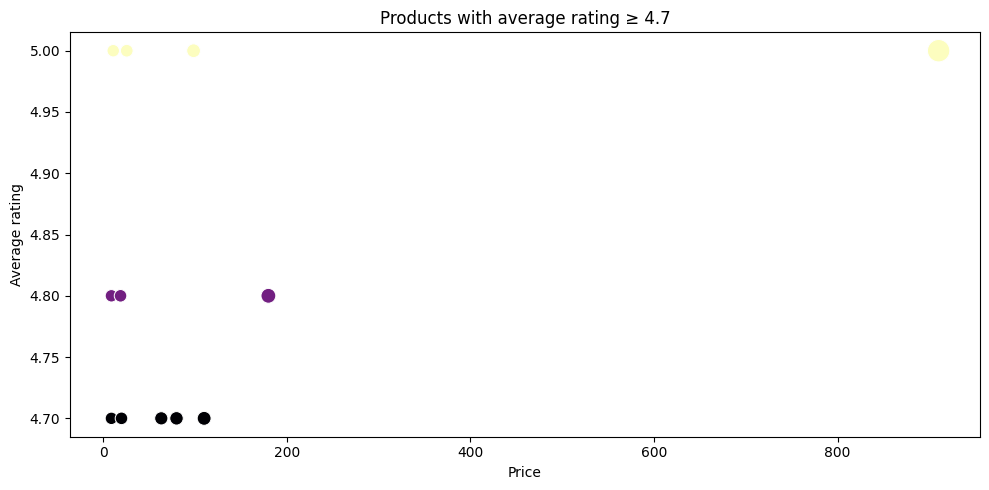

In [17]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=highly_rated_products_df,
    x="price",
    y="average_rating",
    size="price",
    hue="average_rating",
    palette="magma",
    sizes=(80, 260),
    legend=False,
)
plt.title(f"Products with average rating ≥ {highly_rated_products_df_cutoff}")
plt.xlabel("Price")
plt.ylabel("Average rating")
plt.tight_layout()
plt.show()

### A small business focused summary

In [18]:
price_summary = (
    top_products_df.assign(
        price_band=pd.cut(
            top_products_df["price"],
            bins=[-float("inf"), 25, 100, float("inf")],
            labels=["Under $25", "$25–$100", "Over $100"],
        )
    )
    .groupby("price_band", observed=False)
    .agg(product_count=("title", "size"), average_rating=("average_rating", "mean"))
    .reset_index()
)
price_summary

,price_band,product_count,average_rating
0,Under $25,11,4.654545
1,$25–$100,7,4.700000
2,Over $100,3,4.833333


## 7. Reflection

1. Which transformation made the dataset safer to use?
2. What is one useful pattern to investigate further?
3. How can the cleaned table support future machine learning work?
4. Why was a 100 row sample limit used for both datasets?
5. Why are both CSV and Parquet formats useful?
6. What did the visualizations reveal about prices and ratings?
7. How can this project be presented in a portfolio?

In [19]:
reflection_answers = {
    "1. Which transformation made the dataset safer to use?": (
        "Converting price with pd.to_numeric(errors='coerce') made the filter safer. "
        "Text such as 'None' became a missing value that could be removed with a clear boolean condition."
    ),
    "2. What is one useful pattern to investigate further?": (
        "The next useful check is whether price bands show different rating patterns. "
        "The current sample describes highly rated products, but a larger sample is needed before making a pricing claim."
    ),
    "3. How can the cleaned table support future machine learning work?": (
        "The table provides consistent product titles, numeric prices, and numeric ratings. "
        "Those fields can be joined with review text and product identifiers later for recommendation, "
        "ranking, or customer satisfaction models."
    ),
    "4. Why was a 100 row sample limit used for both datasets?": (
        "The source files are very large, so a 100 row limit keeps exploration fast and avoids loading more data than the early analysis needs. "
        "The same limit also makes the review and metadata checks easy to repeat."
    ),
    "5. Why are both CSV and Parquet formats useful?": (
        "CSV is simple to open and share across many tools. Parquet preserves useful column types and is more efficient for analytical workflows, "
        "so keeping both formats supports quick inspection and future processing."
    ),
    "6. What did the visualizations reveal about prices and ratings?": (
        "The cleaned sample contains products across several price levels while all products meet the high rating filter. "
        "The charts help compare the price spread with the rating concentration, but the small sample is not enough to claim that price causes higher ratings."
    ),
    "7. How can this project be presented in a portfolio?": (
        "The project can be presented as a compact data preparation case study. "
        "It demonstrates bounded streaming, pandas cleaning, exception handling, export design, and visual communication in one repeatable workflow."
    ),
}

reflection_lines = ["Electronics Product Quality Snapshot — Reflection\n"]
for question, answer in reflection_answers.items():
    reflection_lines.append(f"{question}\nAnswer: {answer}\n")

Path("user_inputs.txt").write_text("\n".join(reflection_lines), encoding="utf-8")
print(Path("user_inputs.txt").read_text(encoding="utf-8"))

Electronics Product Quality Snapshot — Reflection

1. Which transformation made the dataset safer to use?
Answer: Converting price with pd.to_numeric(errors='coerce') made the filter safer. Text such as 'None' became a missing value that could be removed with a clear boolean condition.

2. What is one useful pattern to investigate further?
Answer: The next useful check is whether price bands show different rating patterns. The current sample describes highly rated products, but a larger sample is needed before making a pricing claim.

3. How can the cleaned table support future machine learning work?
Answer: The table provides consistent product titles, numeric prices, and numeric ratings. Those fields can be joined with review text and product identifiers later for recommendation, ranking, or customer satisfaction models.

4. Why was a 100 row sample limit used for both datasets?
Answer: The source files are very large, so a 100 row limit keeps exploration fast and avoids loading more

## Conclusion

The workflow produces a small, typed product table that is easy to inspect and ready for a larger data pull. The exported files, visual checks, safe exception handling, and reflection notes provide a clear handoff for future modeling work.